# Unbiased Meta-Labeling Evaluation

This notebook compares two evaluation modes from `src/evaluation.py`:
- `static`: fixed train/validation/test split with validation-only policy calibration.
- `walk_forward`: rolling retrain and rolling calibration before each test month.

It supports two decision policies:
- `threshold`: take trade when success probability >= selected threshold.
- `utility`: take trade when utility score >= `UTILITY_MARGIN`.


In [12]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists() and (project_root.parent / 'src').exists():
    project_root = project_root.parent

if not (project_root / 'src').exists():
    raise RuntimeError('Could not locate project root containing src/. Open notebook from project root or notebooks/.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: /home/cristhian/Projects/ssga-meta-labeling


In [13]:
FORWARD_WINDOW = 1
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
THRESHOLD_MIN = 0.30
THRESHOLD_MAX = 0.70
THRESHOLD_STEP = 0.01
OBJECTIVE = 'sharpe'
RANDOM_STATE = 42
TRANSACTION_COST_BPS = 0.0
VALIDATION_WINDOW = 60
MIN_TRAIN_WINDOW = 120

# New options from latest evaluator improvements.
DECISION_POLICY = 'threshold'   # options: 'threshold' or 'utility'
PROBABILITY_CALIBRATION = 'none'  # options: 'none', 'sigmoid', 'isotonic'
UTILITY_MARGIN = 0.0
UTILITY_RISK_AVERSION = 0.0

print('Config ready.')
print(f'Policy={DECISION_POLICY}, Calibration={PROBABILITY_CALIBRATION}, Cost(bps)={TRANSACTION_COST_BPS}')


Config ready.
Policy=threshold, Calibration=none, Cost(bps)=0.0


In [14]:
from src.evaluation import run_evaluation, run_walk_forward_evaluation, save_report, save_test_trade_log

static_report, static_trade_log = run_evaluation(
    forward_window=FORWARD_WINDOW,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    threshold_min=THRESHOLD_MIN,
    threshold_max=THRESHOLD_MAX,
    threshold_step=THRESHOLD_STEP,
    objective=OBJECTIVE,
    random_state=RANDOM_STATE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    decision_policy=DECISION_POLICY,
    probability_calibration=PROBABILITY_CALIBRATION,
    utility_margin=UTILITY_MARGIN,
    utility_risk_aversion=UTILITY_RISK_AVERSION,
)

if DECISION_POLICY == 'threshold':
    print(f"Static selected threshold: {static_report['selected_threshold']:.2f}")
else:
    print('Static utility profile:', static_report['utility_profile'])


Static selected threshold: 0.57


In [15]:
static_splits = pd.DataFrame(static_report['splits']).T
static_test_metrics = pd.DataFrame(
    [static_report['test_metrics']['primary'], static_report['test_metrics']['meta']],
    index=['primary', 'meta']
)

display(static_splits)
display(static_test_metrics[['final_value', 'cagr', 'sharpe', 'max_drawdown', 'trades_taken', 'total_transaction_cost']])

,rows,start_date,end_date,trade_signal_rows
train,208,1997-01-31,2014-04-30,152
validation,69,2014-05-30,2020-01-31,59
test,70,2020-02-28,2025-11-28,56


,final_value,cagr,sharpe,max_drawdown,trades_taken,total_transaction_cost
primary,1.949558,0.121252,0.913195,-0.133073,56,0.0
meta,1.536298,0.076384,0.643695,-0.183054,42,0.0


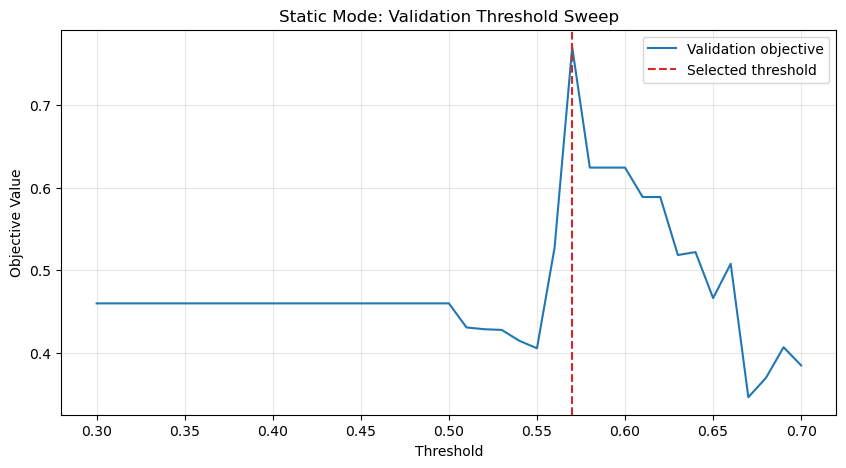

In [16]:
if DECISION_POLICY == 'threshold':
    static_threshold_df = pd.DataFrame(static_report['validation_threshold_table'])

    plt.figure(figsize=(10, 5))
    plt.plot(static_threshold_df['threshold'], static_threshold_df['objective_value'], color='tab:blue', label='Validation objective')
    plt.axvline(static_report['selected_threshold'], color='tab:red', linestyle='--', label='Selected threshold')
    plt.title('Static Mode: Validation Threshold Sweep')
    plt.xlabel('Threshold')
    plt.ylabel('Objective Value')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
else:
    utility_profile_df = pd.DataFrame([static_report['utility_profile']])
    display(utility_profile_df)

    utility_scores = static_trade_log['Utility_Score'].dropna()
    if not utility_scores.empty:
        plt.figure(figsize=(10, 5))
        plt.hist(utility_scores, bins=20, color='tab:purple', alpha=0.8)
        plt.axvline(UTILITY_MARGIN, color='tab:red', linestyle='--', label='Utility margin')
        plt.title('Static Mode: Utility Score Distribution (Test)')
        plt.xlabel('Utility Score')
        plt.ylabel('Frequency')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


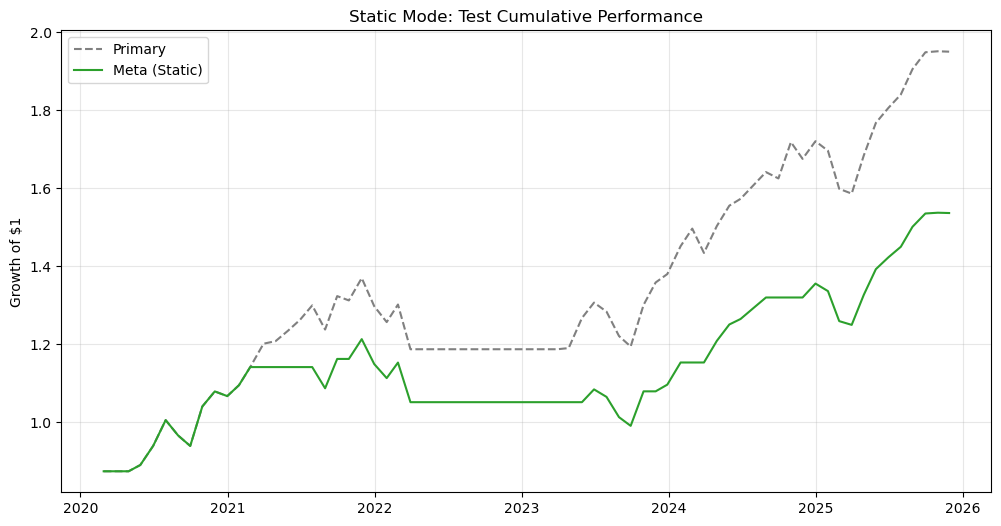

In [17]:
static_plot = static_trade_log.copy()
static_plot['Date'] = pd.to_datetime(static_plot['Date'])

plt.figure(figsize=(12, 6))
plt.plot(static_plot['Date'], static_plot['Cumulative_Primary'], label='Primary', color='gray', linestyle='--')
plt.plot(static_plot['Date'], static_plot['Cumulative_Meta'], label='Meta (Static)', color='tab:green')
plt.title('Static Mode: Test Cumulative Performance')
plt.ylabel('Growth of $1')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [19]:
wf_report, wf_trade_log = run_walk_forward_evaluation(
    forward_window=FORWARD_WINDOW,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    threshold_min=THRESHOLD_MIN,
    threshold_max=THRESHOLD_MAX,
    threshold_step=THRESHOLD_STEP,
    objective=OBJECTIVE,
    random_state=RANDOM_STATE,
    validation_window=VALIDATION_WINDOW,
    min_train_window=MIN_TRAIN_WINDOW,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    decision_policy=DECISION_POLICY,
    probability_calibration=PROBABILITY_CALIBRATION,
    utility_margin=UTILITY_MARGIN,
    utility_risk_aversion=UTILITY_RISK_AVERSION,
)

if DECISION_POLICY == 'threshold':
    print('Walk-forward threshold summary:', wf_report['threshold_summary'])
else:
    print('Walk-forward utility score summary:', wf_report['utility_score_summary'])
print('Walk-forward status counts:', wf_report['walk_forward_summary']['status_counts'])


Walk-forward threshold summary: {'count': 70, 'min': 0.3, 'max': 0.7000000000000004, 'mean': 0.5318571428571429, 'median': 0.6000000000000003, 'std': 0.1296070198401181}
Walk-forward status counts: {'ok': 70}


In [20]:
wf_test_metrics = pd.DataFrame(
    [wf_report['test_metrics']['primary'], wf_report['test_metrics']['meta']],
    index=['primary', 'meta_walk_forward']
)

display(wf_test_metrics[['final_value', 'cagr', 'sharpe', 'max_drawdown', 'trades_taken', 'total_transaction_cost']])

,final_value,cagr,sharpe,max_drawdown,trades_taken,total_transaction_cost
primary,1.949558,0.121252,0.913195,-0.133073,56,0.0
meta_walk_forward,1.477341,0.069187,0.623562,-0.178014,41,0.0


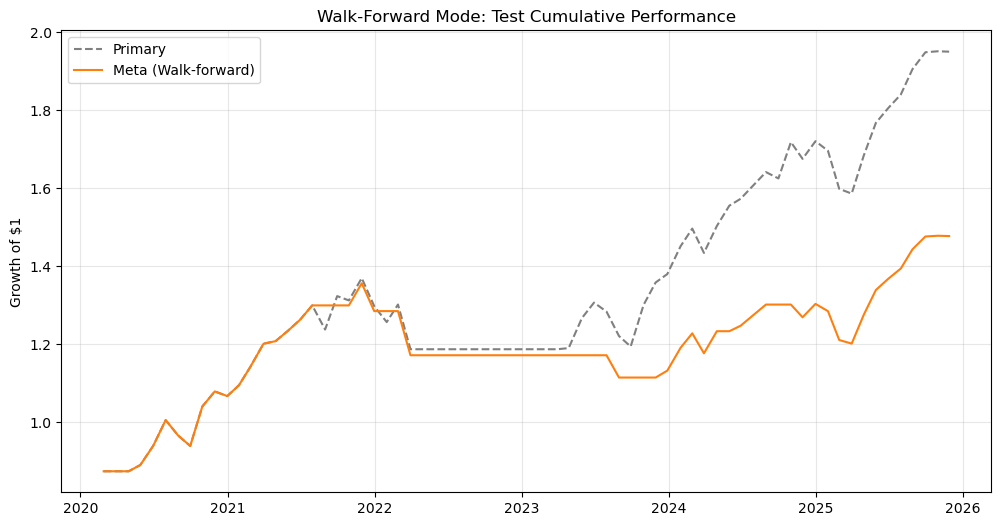

In [21]:
wf_plot = wf_trade_log.copy()
wf_plot['Date'] = pd.to_datetime(wf_plot['Date'])

plt.figure(figsize=(12, 6))
plt.plot(wf_plot['Date'], wf_plot['Cumulative_Primary'], label='Primary', color='gray', linestyle='--')
plt.plot(wf_plot['Date'], wf_plot['Cumulative_Meta'], label='Meta (Walk-forward)', color='tab:orange')
plt.title('Walk-Forward Mode: Test Cumulative Performance')
plt.ylabel('Growth of $1')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

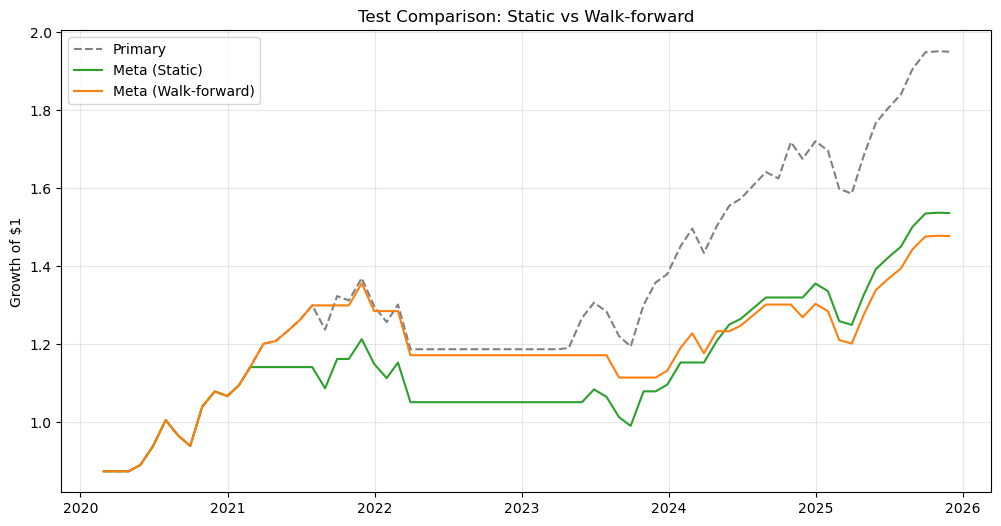

In [22]:
compare_df = pd.DataFrame({
    'Date': pd.to_datetime(static_trade_log['Date']),
    'Primary': static_trade_log['Cumulative_Primary'],
    'Meta_Static': static_trade_log['Cumulative_Meta'],
    'Meta_WalkForward': wf_trade_log['Cumulative_Meta'],
})

plt.figure(figsize=(12, 6))
plt.plot(compare_df['Date'], compare_df['Primary'], label='Primary', color='gray', linestyle='--')
plt.plot(compare_df['Date'], compare_df['Meta_Static'], label='Meta (Static)', color='tab:green')
plt.plot(compare_df['Date'], compare_df['Meta_WalkForward'], label='Meta (Walk-forward)', color='tab:orange')
plt.title('Test Comparison: Static vs Walk-forward')
plt.ylabel('Growth of $1')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [23]:
comparison_metrics = pd.DataFrame({
    'primary_static': static_report['test_metrics']['primary'],
    'meta_static': static_report['test_metrics']['meta'],
    'meta_walk_forward': wf_report['test_metrics']['meta'],
}).T

display(comparison_metrics[['final_value', 'cagr', 'sharpe', 'max_drawdown', 'trades_taken', 'turnover_events', 'total_transaction_cost']])

static_report_path = save_report(static_report, project_root / 'reports' / 'evaluation_report_static_from_notebook.json')
static_trades_path = save_test_trade_log(static_trade_log, project_root / 'reports' / 'test_trade_log_static_from_notebook.csv')
wf_report_path = save_report(wf_report, project_root / 'reports' / 'evaluation_report_walk_forward_from_notebook.json')
wf_trades_path = save_test_trade_log(wf_trade_log, project_root / 'reports' / 'test_trade_log_walk_forward_from_notebook.csv')

print(f'Static report: {static_report_path}')
print(f'Static trades: {static_trades_path}')
print(f'Walk-forward report: {wf_report_path}')
print(f'Walk-forward trades: {wf_trades_path}')

,final_value,cagr,sharpe,max_drawdown,trades_taken,turnover_events,total_transaction_cost
primary_static,1.949558,0.121252,0.913195,-0.133073,56.0,5.0,0.0
meta_static,1.536298,0.076384,0.643695,-0.183054,42.0,15.0,0.0
meta_walk_forward,1.477341,0.069187,0.623562,-0.178014,41.0,15.0,0.0


Static report: /home/cristhian/Projects/ssga-meta-labeling/reports/evaluation_report_static_from_notebook.json
Static trades: /home/cristhian/Projects/ssga-meta-labeling/reports/test_trade_log_static_from_notebook.csv
Walk-forward report: /home/cristhian/Projects/ssga-meta-labeling/reports/evaluation_report_walk_forward_from_notebook.json
Walk-forward trades: /home/cristhian/Projects/ssga-meta-labeling/reports/test_trade_log_walk_forward_from_notebook.csv
